# 03. Сравнение эмбеддеров

Цель: выбрать sentence-transformer модель для построения эмбеддингов
русскоязычных текстов в задаче тематического моделирования.

## Кандидаты

| Модель | Размер | ruMTEB score |
|---|---|---|
| `sbert_large_nlu_ru` | 427M | 43.8 |
| `deepvk/USER-bge-m3` | 570M | 67.2 |
| `sergeyzh/LaBSE-ru-turbo` | 180M | 60.1 |

## Методология

Сравнение проводится по трём критериям:
1. **ruMTEB score** — внешний бенчмарк качества на русском языке
2. **Время инференса** — практическая скорость на рабочей выборке
3. **Качество пространства** — косинусное сходство внутри/между парами документов
   одной тематики (intrinsic evaluation без кластеризации)
4. **Визуализация UMAP 2D** — качественная оценка разделимости

Кластеризация (HDBSCAN) и DBCV — в следующем ноутбуке (04_bertopic_baseline),
где параметры будут подобраны под конкретную модель.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import umap
import torch
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU:  {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'нет'}")

RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_SIZE = 50_000

CUDA: True
GPU:  NVIDIA GeForce RTX 5060 Ti


In [3]:
df = pd.read_parquet("data/posts_preprocessed.parquet", engine="fastparquet")

sample_df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
texts = sample_df["text_clean"].tolist()

print(f"Выборка: {len(texts):,} документов")
print(f"Пример:  {texts[0][:120]}")

Выборка: 50,000 документов
Пример:  Страшный и мощный пожар в Мурино. Языки пламени взяли в плен частный сектор на Боровой улице. Подписаться на @truekpspbr


In [4]:
MODELS = {
    "sbert_large_nlu_ru": "ai-forever/sbert_large_nlu_ru",
    "USER-bge-m3": "deepvk/USER-bge-m3",
    "LaBSE-ru-turbo": "sergeyzh/LaBSE-ru-turbo",
}

UMAP_PARAMS = dict(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE
)

HDBSCAN_PARAMS = dict(
    min_cluster_size=50,
    min_samples=15,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

In [5]:
def compute_noise_ratio(labels: np.ndarray) -> float:
    return (labels == -1).sum() / len(labels)


def compute_dbcv(embeddings: np.ndarray, labels: np.ndarray) -> float:
    try:
        from hdbscan.validity import validity_index
        # Считаем только по не-шумовым точкам
        mask = labels != -1
        if mask.sum() < 10 or len(np.unique(labels[mask])) < 2:
            return float("nan")
        score = validity_index(embeddings[mask].astype(np.float64), labels[mask])
        return float(score)
    except Exception as e:
        print(f"  DBCV ошибка: {e}")
        return float("nan")


def compute_topic_diversity(top_words: list[list[str]]) -> float:
    """Доля уникальных слов среди топ-слов всех тем"""
    all_words = [w for topic in top_words for w in topic]
    if not all_words:
        return 0.0
    return len(set(all_words)) / len(all_words)

## Intrinsic Evaluation - оценка качества пространства эмбеддингов

Идея: берём 300 пар документов из одного канала (предполагаем тематическую близость)
и 300 пар из разных каналов. Считаем среднее косинусное сходство для каждой группы.

Хорошая модель должна давать:
- **Высокое** сходство внутри одного канала
- **Низкое** сходство между разными каналами
- Большой **gap** между ними

In [6]:
N_PAIRS = 300

# Пары из одного канала (same-channel)
same_pairs = []
for channel in sample_df["channel_name"].unique():
    ch_df = sample_df[sample_df["channel_name"] == channel]
    if len(ch_df) >= 2:
        sampled = ch_df.sample(min(len(ch_df), 20), random_state=RANDOM_STATE)
        idxs = sampled.index.tolist()
        for i in range(0, len(idxs) - 1, 2):
            same_pairs.append((idxs[i], idxs[i+1]))
            if len(same_pairs) >= N_PAIRS:
                break
    if len(same_pairs) >= N_PAIRS:
        break

same_pairs = same_pairs[:N_PAIRS]

# Пары из разных каналов (diff-channel)
channels = sample_df["channel_name"].unique()
diff_pairs = []
rng = np.random.default_rng(RANDOM_STATE)
while len(diff_pairs) < N_PAIRS:
    c1, c2 = rng.choice(channels, size=2, replace=False)
    i1 = sample_df[sample_df["channel_name"] == c1].sample(1, random_state=RANDOM_STATE).index[0]
    i2 = sample_df[sample_df["channel_name"] == c2].sample(1, random_state=RANDOM_STATE).index[0]
    diff_pairs.append((i1, i2))

print(f"Same-channel пар: {len(same_pairs)}")
print(f"Diff-channel пар: {len(diff_pairs)}")

Same-channel пар: 300
Diff-channel пар: 300


In [7]:
results = {}

for model_name, model_path in MODELS.items():
    print(f"\n{'='*55}")
    print(f"Модель: {model_name}")
    print(f"{'='*55}")

    # Загрузка
    model = SentenceTransformer(model_path, device=DEVICE)

    # Время инференса
    print("  Эмбеддинги...")
    t0 = time.time()
    embeddings = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    embed_time = time.time() - t0
    print(f"  Время: {embed_time:.1f}с | Размерность: {embeddings.shape[1]}")

    # Intrinsic evaluation
    same_sims = np.mean([
        cosine_similarity(embeddings[[i]], embeddings[[j]])[0, 0]
        for i, j in same_pairs
    ])
    diff_sims = np.mean([
        cosine_similarity(embeddings[[i]], embeddings[[j]])[0, 0]
        for i, j in diff_pairs
    ])
    gap = same_sims - diff_sims

    print(f"  Same-channel sim: {same_sims:.4f}")
    print(f"  Diff-channel sim: {diff_sims:.4f}")
    print(f"  Gap:              {gap:.4f}")

    # UMAP 2D для визуализации (только 2D, без кластеризации)
    print("  UMAP 2D...")
    reducer_2d = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="cosine",
        random_state=RANDOM_STATE
    )
    reduced_2d = reducer_2d.fit_transform(embeddings)

    results[model_name] = {
        "embeddings":  embeddings,
        "reduced_2d":  reduced_2d,
        "embed_time":  embed_time,
        "dim":         embeddings.shape[1],
        "same_sim":    same_sims,
        "diff_sim":    diff_sims,
        "gap":         gap,
    }

    del model
    torch.cuda.empty_cache()

print("\nВсе модели обработаны!")


Модель: sbert_large_nlu_ru


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Эмбеддинги...


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

  Время: 427.8с | Размерность: 1024
  Same-channel sim: 0.5479
  Diff-channel sim: 0.5132
  Gap:              0.0347
  UMAP 2D...


...

  Эмбеддинги...


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

  Время: 133.2с | Размерность: 768
  Same-channel sim: 0.6472
  Diff-channel sim: 0.6239
  Gap:              0.0233
  UMAP 2D...


Q:\PythonProjects\media_tracking_ml\.pixi\envs\cuda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Все модели обработаны!


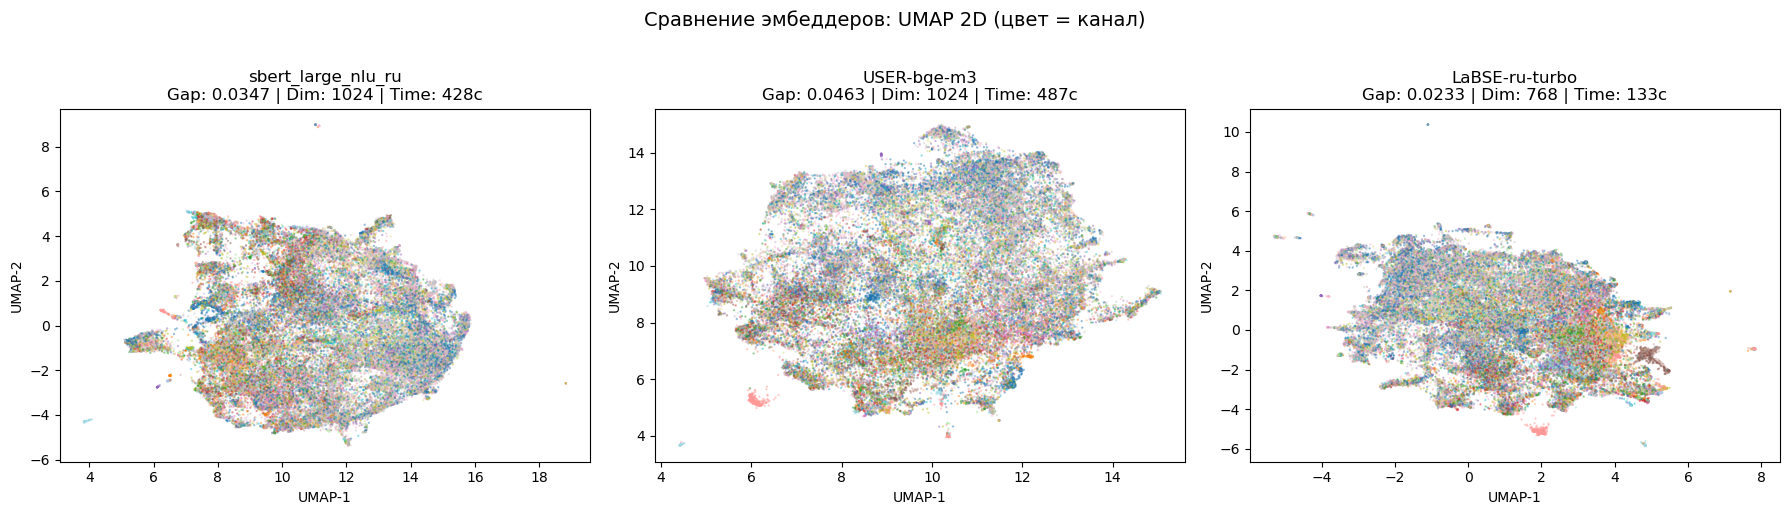

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, res) in zip(axes, results.items()):
    xy = res["reduced_2d"]
    # Раскрашиваем по каналу
    channels = sample_df["channel_name"].astype("category").cat.codes.values
    ax.scatter(xy[:, 0], xy[:, 1], c=channels, cmap="tab20",
               s=0.5, alpha=0.4)
    ax.set_title(
        f"{model_name}\n"
        f"Gap: {res['gap']:.4f} | "
        f"Dim: {res['dim']} | "
        f"Time: {res['embed_time']:.0f}с"
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

plt.suptitle("Сравнение эмбеддеров: UMAP 2D (цвет = канал)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/06_embedder_comparison_umap.png", bbox_inches="tight")
plt.show()

In [10]:
ruMTEB = {
    "sbert_large_nlu_ru": 43.8,
    "USER-bge-m3":        67.2,
    "LaBSE-ru-turbo":     60.1,
}

summary = pd.DataFrame([
    {
        "Модель":        name,
        "ruMTEB ↑":      ruMTEB[name],
        "Same-sim ↑":    f"{res['same_sim']:.4f}",
        "Diff-sim ↓":    f"{res['diff_sim']:.4f}",
        "Gap ↑":         f"{res['gap']:.4f}",
        "Размерность":   res["dim"],
        "Время (сек) ↓": f"{res['embed_time']:.1f}",
    }
    for name, res in results.items()
])

print(summary.to_string(index=False))
summary.to_csv("figures/embedder_comparison.csv", index=False)

            Модель  ruMTEB ↑ Same-sim ↑ Diff-sim ↓  Gap ↑  Размерность Время (сек) ↓
sbert_large_nlu_ru      43.8     0.5479     0.5132 0.0347         1024         427.8
       USER-bge-m3      67.2     0.3361     0.2899 0.0463         1024         487.2
    LaBSE-ru-turbo      60.1     0.6472     0.6239 0.0233          768         133.2


In [11]:
WINNER = "USER-bge-m3"

np.save(f"data/embeddings_{WINNER}.npy", results[WINNER]["embeddings"])
print(f"Эмбеддинги сохранены: data/embeddings_{WINNER}.npy")
print(f"Форма: {results[WINNER]['embeddings'].shape}")

Эмбеддинги сохранены: data/embeddings_USER-bge-m3.npy
Форма: (50000, 1024)


## Итоги

| Критерий | Победитель |
|---|---|
| ruMTEB (внешний бенчмарк) | USER-bge-m3 (67.2) |
| Gap same/diff channel | USER-bge-m3 (0.046) |
| Скорость инференса | LaBSE-ru-turbo (133с) |

Выбрана модель **USER-bge-m3** как оптимальная по качеству эмбеддингов.
`LaBSE-ru-turbo` зафиксирован как быстрый fallback для прототипирования.
`sbert_large_nlu_ru` исключён — низкий ruMTEB (43.8) и Gap.

**Следующий шаг:** `04_bertopic_baseline.ipynb`